# Single-Task GRU (R1) — full 200-epoch baseline

This notebook is the **final STL-R1 baseline protocol** for comparison with MTL.

**Key rule**
- No early stopping.
- Every seed trains for the full `200` epochs.
- For each seed, the final model is the checkpoint with the **lowest validation R1 task loss across all 200 epochs**.
- Test data are never used for checkpoint selection.

Everything else remains unchanged from the validated STL-R1 model:
1. Same 10-dim historical input.
2. Same 1-layer GRU encoder + GRUCell decoder + 3-channel R1 head.
3. Same hidden size, batch size, learning rate, weight decay and dropout.
4. Same battery-level split and leakage check.
5. Same five seeds `[42, 43, 44, 45, 46]`.
6. Same equal weighting over the three SOC channels after each channel's own mask normalization.
7. Same standardized + physical resistance metrics and horizon analysis.

The full train/validation R1 loss history is saved for all 200 epochs.


In [1]:
import sys
import torch
import numpy as np
import pandas as pd

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

print(torch.rand(2, 3))


Python: d:\venvs\torch_test\Scripts\python.exe
PyTorch: 2.8.0+cpu
NumPy: 2.5.3
Pandas: 3.0.5
tensor([[0.4250, 0.6728, 0.3625],
        [0.4182, 0.3615, 0.0503]])


In [2]:
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEEDS = [42, 43, 44, 45, 46]
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)
print('seeds:', SEEDS)

# Keep the original STL-R1 hyperparameters unchanged.
HID          = 64
ENC_LAYERS   = 1
DROPOUT      = 0.2
LR           = 3e-3
WEIGHT_DECAY = 1e-4
EPOCHS       = 200
BATCH_SIZE   = 32

# No PATIENCE: every seed runs all 200 epochs.
TRAIN_EVAL_BATCH = 256


device: cpu
seeds: [42, 43, 44, 45, 46]


In [3]:
# ---- load data + scaler ----
DATA_CANDIDATES   = [Path('seq_dataset_10dim_v7.npz'), Path('/mnt/data/seq_dataset_10dim_v7.npz')]
SCALER_CANDIDATES = [Path('scaler_10dim_v7.json'),     Path('/mnt/data/scaler_10dim_v7.json')]
DATA_PATH   = next((p for p in DATA_CANDIDATES if p.exists()), None)
SCALER_PATH = next((p for p in SCALER_CANDIDATES if p.exists()), None)

if DATA_PATH is None or SCALER_PATH is None:
    raise FileNotFoundError(
        '请把 seq_dataset_10dim_v7.npz 和 scaler_10dim_v7.json 放到同目录或 /mnt/data/。'
    )

data = np.load(DATA_PATH, allow_pickle=True)
features = data['features'].tolist()
F = len(features)

cfg = json.load(open(SCALER_PATH, encoding='utf-8'))
assert cfg['features'] == features, 'scaler 与数据集特征顺序不一致'
assert bool(cfg.get('log_r', False)), '当前 R 物理还原要求 scaler 中 log_r=True'

MEAN = np.asarray(cfg['mean'], dtype=float)
STD  = np.asarray(cfg['std'], dtype=float)
R_COLS = set(cfg['r_cols'])

TARGET_TASK = 'R1'
TARGET_COMPONENTS = ['SOC10_R1', 'SOC50_R1', 'SOC90_R1']
TARGET_IDXS = [features.index(name) for name in TARGET_COMPONENTS]
OUT_DIM = len(TARGET_IDXS)

assert OUT_DIM == 3
assert all(name in R_COLS for name in TARGET_COMPONENTS)

def inverse_component(z, feature_idx):
    """Inverse standardized/log1p resistance to original physical scale."""
    x_log = np.asarray(z, dtype=float) * STD[feature_idx] + MEAN[feature_idx]
    return np.expm1(x_log)

def get(split):
    # Same 10-dim input handling as STL-SOH
    X = np.where(
        data[f'{split}_X_fmask'].astype(bool),
        data[f'{split}_X'].astype(np.float32),
        0.0
    )
    Xt = data[f'{split}_X_tmask'].astype(bool)

    # Only the supervised target changes: 3 channels of R1
    Y = data[f'{split}_Y'][:, :, TARGET_IDXS].astype(np.float32)
    Ym = data[f'{split}_Y_mask'][:, :, TARGET_IDXS].astype(bool)
    bid = data[f'{split}_bid']
    return X.astype(np.float32), Xt, Y, Ym, bid

Xtr, Xttr, Ytr, Ymtr, btr = get('train')
Xva, Xtva, Yva, Ymva, bva = get('val')
Xte, Xtte, Yte, Ymte, bte = get('test')
HORIZON = Ytr.shape[1]

utr, uva, ute = np.unique(btr), np.unique(bva), np.unique(bte)

print('features:', features)
print('target task:', TARGET_TASK)
print('target components:', TARGET_COMPONENTS)
print('sample/window counts:', len(btr), len(bva), len(bte))
print('unique battery counts:', len(utr), len(uva), len(ute))
print('horizon:', HORIZON)

assert np.intersect1d(utr, uva).size == 0, 'Leakage: train and val share battery IDs'
assert np.intersect1d(utr, ute).size == 0, 'Leakage: train and test share battery IDs'
assert np.intersect1d(uva, ute).size == 0, 'Leakage: val and test share battery IDs'

print('Battery leakage check passed.')


features: ['SOH', 'SOC10_R0', 'SOC50_R0', 'SOC90_R0', 'SOC10_R1', 'SOC50_R1', 'SOC90_R1', 'SOC10_R2', 'SOC50_R2', 'SOC90_R2']
target task: R1
target components: ['SOC10_R1', 'SOC50_R1', 'SOC90_R1']
sample/window counts: 4581 45 45
unique battery counts: 212 45 45
horizon: 29
Battery leakage check passed.


In [4]:
# ---- model: SAME encoder/decoder backbone, single R1 head with 3 outputs ----
class GRUSeq2Seq(nn.Module):
    def __init__(self, in_dim, out_dim=3, hid=64, layers=1, horizon=29, p=0.2):
        super().__init__()
        self.encoder = nn.GRU(
            in_dim, hid, layers,
            batch_first=True,
            dropout=p if layers > 1 else 0.0
        )
        self.dec_cell = nn.GRUCell(hid, hid)
        self.drop = nn.Dropout(p)
        self.head = nn.Linear(hid, out_dim)
        self.horizon = horizon

    def forward(self, x, x_tmask):
        lengths = x_tmask.sum(1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths,
            batch_first=True,
            enforce_sorted=False
        )
        _, h = self.encoder(packed)
        s = h[-1]                         # (B, hid)
        z = torch.zeros_like(s)

        outs = []
        for _ in range(self.horizon):
            s = self.dec_cell(z, s)
            sd = self.drop(s)
            outs.append(self.head(sd).unsqueeze(1))   # (B, 1, 3)
            z = s

        return torch.cat(outs, dim=1)     # (B, horizon, 3)

def equal_channel_masked_mse(pred, y, m):
    """
    pred/y/m: (B, H, 3)

    Each SOC channel is normalized by its own number of valid targets,
    then the three channel losses are equally averaged.
    """
    m = m.float()
    sq_sum = (((pred - y) ** 2) * m).sum(dim=(0, 1))
    n_valid = m.sum(dim=(0, 1))
    active = n_valid > 0

    if not torch.any(active):
        raise RuntimeError('No valid target values in this batch.')

    channel_mse = sq_sum[active] / n_valid[active]
    return channel_mse.mean()


seed=42 | epoch=  1/200 | train=0.346097 | val=0.491004 | best=0.491004 @ 1
seed=42 | epoch= 20/200 | train=0.202441 | val=0.321848 | best=0.301587 @ 16
seed=42 | epoch= 40/200 | train=0.182858 | val=0.320305 | best=0.292930 @ 38
seed=42 | epoch= 60/200 | train=0.161339 | val=0.325047 | best=0.292930 @ 38
seed=42 | epoch= 80/200 | train=0.150744 | val=0.322225 | best=0.292930 @ 38
seed=42 | epoch=100/200 | train=0.149041 | val=0.339482 | best=0.292930 @ 38
seed=42 | epoch=120/200 | train=0.155113 | val=0.378309 | best=0.292930 @ 38
seed=42 | epoch=140/200 | train=0.142216 | val=0.315618 | best=0.292930 @ 38
seed=42 | epoch=160/200 | train=0.160510 | val=0.320971 | best=0.292930 @ 38
seed=42 | epoch=180/200 | train=0.134777 | val=0.383866 | best=0.292930 @ 38
seed=42 | epoch=200/200 | train=0.133869 | val=0.340517 | best=0.292930 @ 38
FINAL seed=42 | best val R1 MSE=0.292930 | best epoch=38 | trained=200
seed=43 | epoch=  1/200 | train=0.355022 | val=0.581702 | best=0.581702 @ 1
seed=43

,seed,best_val_R1_MSE_std,best_epoch,epochs_trained
0,42,0.292930,38,200
1,43,0.302093,20,200
2,44,0.303269,16,200
3,45,0.298087,49,200
4,46,0.299757,21,200


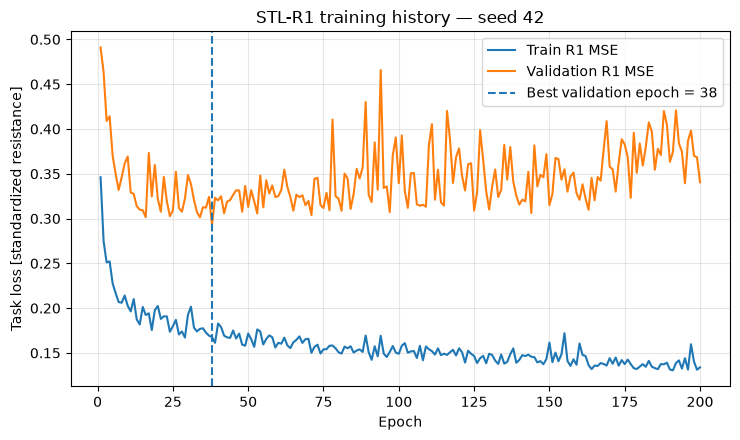

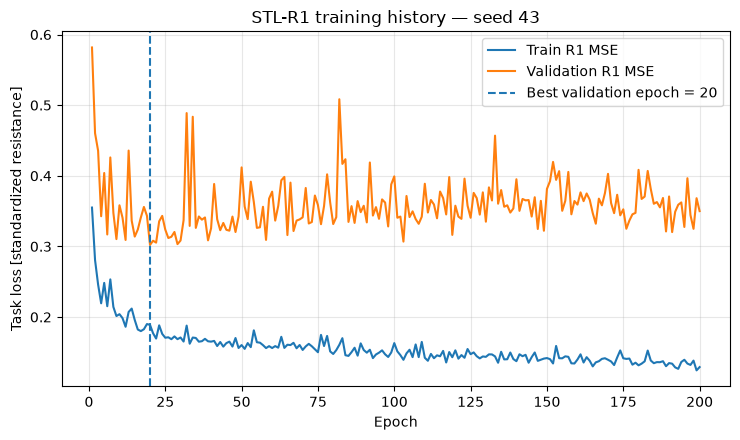

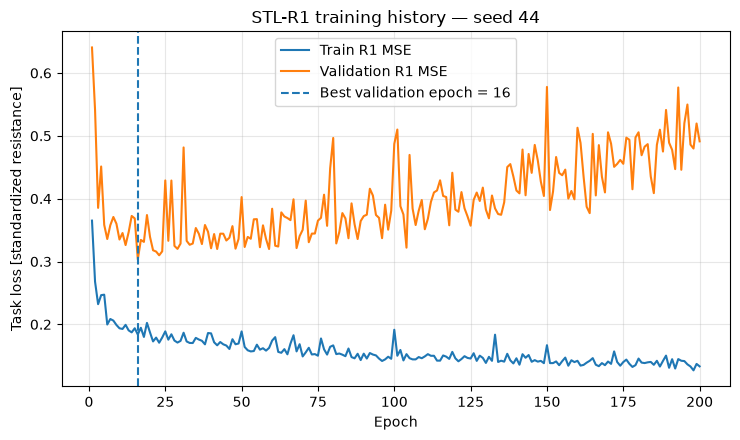

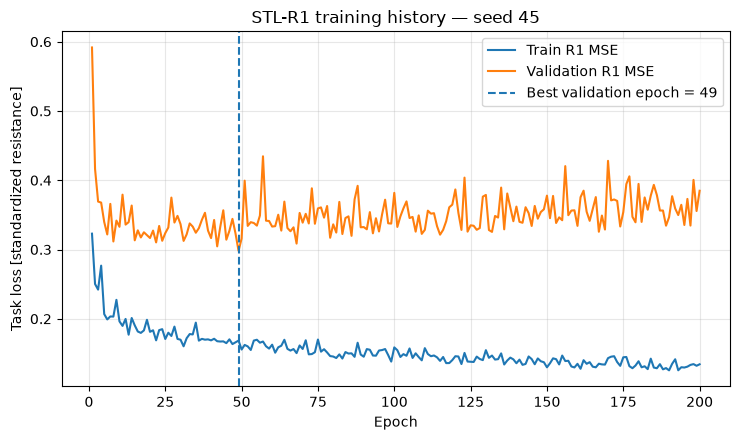

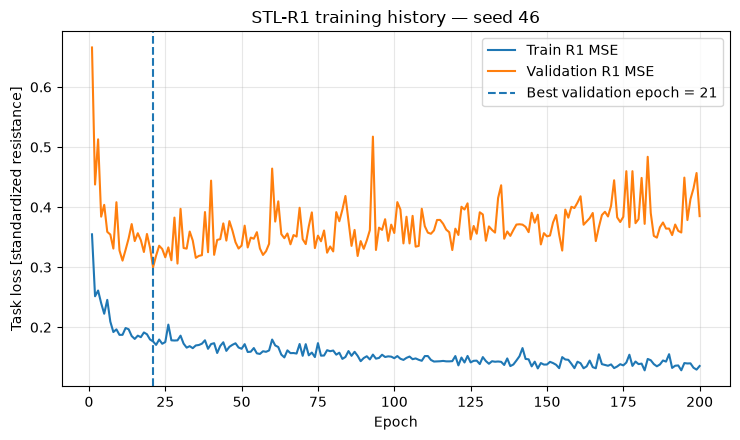

In [5]:
# ---- full 200-epoch training for five seeds ----
def to_t(*a):
    return [torch.tensor(x).to(DEVICE) for x in a]

xtr, xttr, ytr, ymtr = to_t(Xtr, Xttr, Ytr, Ymtr)
xva, xtva, yva, ymva = to_t(Xva, Xtva, Yva, Ymva)
xte, xtte, yte, ymte = to_t(Xte, Xtte, Yte, Ymte)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def exact_equal_channel_mse_in_batches(model, x, xt, y, ym, batch_size=256):
    """
    Exact task loss over the whole dataset:
    1) accumulate SSE and valid counts separately for each SOC channel;
    2) compute each channel's masked MSE;
    3) equally average the active channels.
    """
    model.eval()

    c = y.shape[-1]
    sse = torch.zeros(c, dtype=torch.float64, device=DEVICE)
    n_valid = torch.zeros(c, dtype=torch.float64, device=DEVICE)

    with torch.no_grad():
        for i in range(0, len(x), batch_size):
            xb = x[i:i+batch_size]
            xtb = xt[i:i+batch_size]
            yb = y[i:i+batch_size]
            mb = ym[i:i+batch_size].float()

            pred = model(xb, xtb)

            sse += ((((pred - yb) ** 2) * mb).sum(dim=(0, 1))).double()
            n_valid += mb.sum(dim=(0, 1)).double()

    active = n_valid > 0
    channel_mse = sse[active] / n_valid[active]
    return float(channel_mse.mean().item())

def train_one_seed(seed):
    set_seed(seed)

    model = GRUSeq2Seq(
        F,
        out_dim=OUT_DIM,
        hid=HID,
        layers=ENC_LAYERS,
        horizon=HORIZON,
        p=DROPOUT
    ).to(DEVICE)

    opt = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    best_val = math.inf
    best_state = None
    best_epoch = None
    history = []
    N = len(xtr)

    # IMPORTANT: every seed completes all 200 epochs.
    for ep in range(1, EPOCHS + 1):
        model.train()
        perm = torch.randperm(N)

        for i in range(0, N, BATCH_SIZE):
            idx = perm[i:i+BATCH_SIZE]

            opt.zero_grad()
            pred = model(xtr[idx], xttr[idx])
            loss = equal_channel_masked_mse(
                pred,
                ytr[idx],
                ymtr[idx]
            )
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        train_mse = exact_equal_channel_mse_in_batches(
            model, xtr, xttr, ytr, ymtr,
            batch_size=TRAIN_EVAL_BATCH
        )
        val_mse = exact_equal_channel_mse_in_batches(
            model, xva, xtva, yva, ymva,
            batch_size=TRAIN_EVAL_BATCH
        )

        improved = val_mse < best_val - 1e-6
        if improved:
            best_val = val_mse
            best_epoch = ep
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        history.append({
            'seed': seed,
            'epoch': ep,
            'train_R1_MSE_std': train_mse,
            'val_R1_MSE_std': val_mse,
            'is_best_so_far': bool(improved),
        })

        if ep == 1 or ep % 20 == 0 or ep == EPOCHS:
            print(
                f"seed={seed} | epoch={ep:3d}/{EPOCHS} "
                f"| train={train_mse:.6f} | val={val_mse:.6f} "
                f"| best={best_val:.6f} @ {best_epoch}"
            )

    # Restore the validation-best checkpoint selected from epochs 1..200.
    model.load_state_dict(best_state)

    info = {
        'seed': seed,
        'best_val_R1_MSE_std': best_val,
        'best_epoch': best_epoch,
        'epochs_trained': EPOCHS,
    }
    return model, info, history

models = {}
training_rows = []
history_rows = []

for seed in SEEDS:
    model_seed, info, hist = train_one_seed(seed)
    models[seed] = model_seed
    training_rows.append(info)
    history_rows.extend(hist)

    print(
        f"FINAL seed={seed} | best val R1 MSE="
        f"{info['best_val_R1_MSE_std']:.6f} "
        f"| best epoch={info['best_epoch']} "
        f"| trained={info['epochs_trained']}"
    )

training_summary = pd.DataFrame(training_rows)
training_history = pd.DataFrame(history_rows)

print('\nValidation-best checkpoint for each seed:')
display(training_summary)

# Diagnostic curves: one separate figure per seed.
for seed in SEEDS:
    d = training_history[training_history['seed'] == seed]
    best_ep = int(training_summary.loc[
        training_summary['seed'] == seed, 'best_epoch'
    ].iloc[0])

    plt.figure(figsize=(7.5, 4.5))
    plt.plot(d['epoch'], d['train_R1_MSE_std'], label='Train R1 MSE')
    plt.plot(d['epoch'], d['val_R1_MSE_std'], label='Validation R1 MSE')
    plt.axvline(
        best_ep,
        linestyle='--',
        label=f'Best validation epoch = {best_ep}'
    )
    plt.xlabel('Epoch')
    plt.ylabel('Task loss [standardized resistance]')
    plt.title(f'STL-R1 training history — seed {seed}')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [6]:
# ---- evaluate: component-level first, then equal macro-over-SOC task summary ----
def predict(model, x, xt):
    model.eval()
    with torch.no_grad():
        return model(x, xt).cpu().numpy()   # (N, H, 3)

def r2_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_pred - y_true) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

def build_point_table(seed, split, pred_std, Y, Ym, bid):
    rows = []

    for c, (component, feature_idx) in enumerate(zip(TARGET_COMPONENTS, TARGET_IDXS)):
        for i in range(len(Y)):
            hs = np.flatnonzero(Ym[i, :, c])
            if len(hs) == 0:
                continue

            yt_std = Y[i, hs, c].astype(float)
            yp_std = pred_std[i, hs, c].astype(float)

            yt_phys = inverse_component(yt_std, feature_idx)
            yp_phys = inverse_component(yp_std, feature_idx)

            for k, h in enumerate(hs):
                denom = max(abs(float(yt_phys[k])), 1e-12)

                rows.append({
                    'seed': seed,
                    'split': split,
                    'bid': int(bid[i]),
                    'task': TARGET_TASK,
                    'component': component,
                    'horizon': int(h) + 1,
                    'yt_std': float(yt_std[k]),
                    'yp_std': float(yp_std[k]),
                    'yt_phys': float(yt_phys[k]),
                    'yp_phys': float(yp_phys[k]),
                    'abs_std': abs(float(yp_std[k] - yt_std[k])),
                    'sq_std': float((yp_std[k] - yt_std[k]) ** 2),
                    'abs_phys': abs(float(yp_phys[k] - yt_phys[k])),
                    'sq_phys': float((yp_phys[k] - yt_phys[k]) ** 2),
                    'ape_phys': abs(float(yp_phys[k] - yt_phys[k])) / denom * 100.0,
                })

    return pd.DataFrame(rows)

def component_metrics_from_points(df):
    rows = []

    for (seed, split, component), d in df.groupby(
        ['seed', 'split', 'component'],
        sort=False
    ):
        per_cell = (
            d.groupby('bid')
             .agg(
                 mae_std=('abs_std', 'mean'),
                 mae_phys=('abs_phys', 'mean'),
                 mape_phys=('ape_phys', 'mean'),
             )
        )

        rows.append({
            'seed': seed,
            'split': split,
            'task': TARGET_TASK,
            'component': component,

            'MAE macro [std]': per_cell['mae_std'].mean(),
            'MAE pooled [std]': d['abs_std'].mean(),
            'RMSE pooled [std]': math.sqrt(d['sq_std'].mean()),
            'R2 pooled [std]': r2_np(d['yt_std'], d['yp_std']),

            'MAE macro [physical]': per_cell['mae_phys'].mean(),
            'MAE pooled [physical]': d['abs_phys'].mean(),
            'RMSE pooled [physical]': math.sqrt(d['sq_phys'].mean()),
            'R2 pooled [physical]': r2_np(d['yt_phys'], d['yp_phys']),
            'MAPE macro [%]': per_cell['mape_phys'].mean(),

            'N cells': int(d['bid'].nunique()),
            'N points': int(len(d)),
        })

    return pd.DataFrame(rows)

metric_cols = [
    'MAE macro [std]',
    'MAE pooled [std]',
    'RMSE pooled [std]',
    'R2 pooled [std]',
    'MAE macro [physical]',
    'MAE pooled [physical]',
    'RMSE pooled [physical]',
    'R2 pooled [physical]',
    'MAPE macro [%]',
]

point_tables = []

for seed in SEEDS:
    pred_val = predict(models[seed], xva, xtva)
    pred_test = predict(models[seed], xte, xtte)

    point_tables.append(
        build_point_table(seed, 'val', pred_val, Yva, Ymva, bva)
    )
    point_tables.append(
        build_point_table(seed, 'test', pred_test, Yte, Ymte, bte)
    )

points_all = pd.concat(point_tables, ignore_index=True)

# 3 SOC component metrics
component_metrics = component_metrics_from_points(points_all)

# Main R1 task metric: equal average over the 3 SOC components
task_metrics = (
    component_metrics
    .groupby(['seed', 'split', 'task'], as_index=False)[metric_cols]
    .mean()
)
task_metrics['unit'] = 'R original unit'

# Five-seed task summary
summary_rows = []
for (split, task_name), d in task_metrics.groupby(['split', 'task'], sort=False):
    row = {
        'split': split,
        'task': task_name,
        'unit': 'R original unit',
        'N seeds': d['seed'].nunique(),
    }
    for col in metric_cols:
        row[f'{col} mean'] = d[col].mean()
        row[f'{col} std'] = d[col].std(ddof=1)
    summary_rows.append(row)

task_summary = pd.DataFrame(summary_rows)

# Five-seed detailed component summary
component_summary_rows = []
for (split, component), d in component_metrics.groupby(
    ['split', 'component'],
    sort=False
):
    row = {
        'split': split,
        'task': TARGET_TASK,
        'component': component,
        'N seeds': d['seed'].nunique(),
        'N cells': int(round(d['N cells'].mean())),
        'N points': int(round(d['N points'].mean())),
    }
    for col in metric_cols:
        row[f'{col} mean'] = d[col].mean()
        row[f'{col} std'] = d[col].std(ddof=1)
    component_summary_rows.append(row)

component_summary = pd.DataFrame(component_summary_rows)

print('Per-seed R1 task results:')
display(task_metrics.round(4))

print('\nFive-seed R1 task summary:')
display(task_summary.round(4))

print('\nDetailed three-SOC component summary:')
display(component_summary.round(4))


Per-seed R1 task results:


,seed,split,task,MAE macro [std],MAE pooled [std],RMSE pooled [std],R2 pooled [std],MAE macro [physical],MAE pooled [physical],RMSE pooled [physical],R2 pooled [physical],MAPE macro [%],unit
0,42,test,R1,0.2954,0.2982,0.4531,0.8330,1.6262,1.5152,2.5350,0.7933,7.1403,R original unit
1,42,val,R1,0.3216,0.3292,0.5336,0.8576,2.0593,1.9514,4.0491,0.7943,7.5899,R original unit
2,43,test,R1,0.2935,0.3007,0.4567,0.8300,1.5477,1.5122,2.5009,0.7993,6.9387,R original unit
3,43,val,R1,0.3348,0.3375,0.5421,0.8538,2.1356,1.9776,3.9222,0.7998,7.8755,R original unit
4,44,test,R1,0.3045,0.3120,0.4620,0.8181,1.7314,1.6727,2.7300,0.7708,7.6626,R original unit
5,44,val,R1,0.3294,0.3374,0.5434,0.8521,2.1084,2.0045,3.9837,0.7969,7.9465,R original unit
6,45,test,R1,0.2983,0.3062,0.4529,0.8315,1.5981,1.5635,2.5890,0.7887,7.2739,R original unit
7,45,val,R1,0.3330,0.3410,0.5392,0.8538,2.0981,2.0092,3.9999,0.7956,7.9943,R original unit
8,46,test,R1,0.3176,0.3257,0.4592,0.8297,1.6638,1.6097,2.4876,0.7971,7.7451,R original unit
9,46,val,R1,0.3367,0.3471,0.5422,0.8504,2.1846,2.0680,4.1454,0.7850,8.1801,R original unit



Five-seed R1 task summary:


,split,task,unit,N seeds,MAE macro [std] mean,MAE macro [std] std,MAE pooled [std] mean,MAE pooled [std] std,RMSE pooled [std] mean,RMSE pooled [std] std,...,MAE macro [physical] mean,MAE macro [physical] std,MAE pooled [physical] mean,MAE pooled [physical] std,RMSE pooled [physical] mean,RMSE pooled [physical] std,R2 pooled [physical] mean,R2 pooled [physical] std,MAPE macro [%] mean,MAPE macro [%] std
0,test,R1,R original unit,5,0.3019,0.0097,0.3086,0.0110,0.4568,0.0039,...,1.6334,0.0692,1.5747,0.0678,2.5685,0.0984,0.7898,0.0114,7.3521,0.3438
1,val,R1,R original unit,5,0.3311,0.0059,0.3384,0.0065,0.5401,0.0039,...,2.1172,0.0466,2.0021,0.0435,4.0200,0.0834,0.7943,0.0056,7.9172,0.2149



Detailed three-SOC component summary:


,split,task,component,N seeds,N cells,N points,MAE macro [std] mean,MAE macro [std] std,MAE pooled [std] mean,MAE pooled [std] std,...,MAE macro [physical] mean,MAE macro [physical] std,MAE pooled [physical] mean,MAE pooled [physical] std,RMSE pooled [physical] mean,RMSE pooled [physical] std,R2 pooled [physical] mean,R2 pooled [physical] std,MAPE macro [%] mean,MAPE macro [%] std
0,val,R1,SOC10_R1,5,45,658,0.3604,0.0058,0.3742,0.0045,...,1.4180,0.0257,1.5018,0.0260,3.7628,0.0171,0.7890,0.0019,5.5532,0.1232
1,val,R1,SOC50_R1,5,45,656,0.3139,0.0096,0.3280,0.0106,...,0.8612,0.0248,0.9063,0.0266,1.9177,0.0396,0.8282,0.0071,5.5464,0.1959
2,val,R1,SOC90_R1,5,44,467,0.3189,0.0101,0.3131,0.0116,...,4.0725,0.1337,3.5983,0.1263,6.3796,0.2735,0.7657,0.0202,12.6521,0.5016
3,test,R1,SOC10_R1,5,45,613,0.3108,0.0107,0.3151,0.0097,...,1.0629,0.0434,1.0653,0.0379,1.9067,0.0716,0.8519,0.0110,4.8912,0.1938
4,test,R1,SOC50_R1,5,45,616,0.3191,0.0215,0.3321,0.0216,...,0.8120,0.0509,0.8460,0.0501,1.5123,0.0201,0.7823,0.0058,5.7849,0.4626
5,test,R1,SOC90_R1,5,44,450,0.2757,0.0147,0.2785,0.0160,...,3.0254,0.2182,2.8127,0.2082,4.2866,0.3759,0.7354,0.0477,11.3803,0.8173


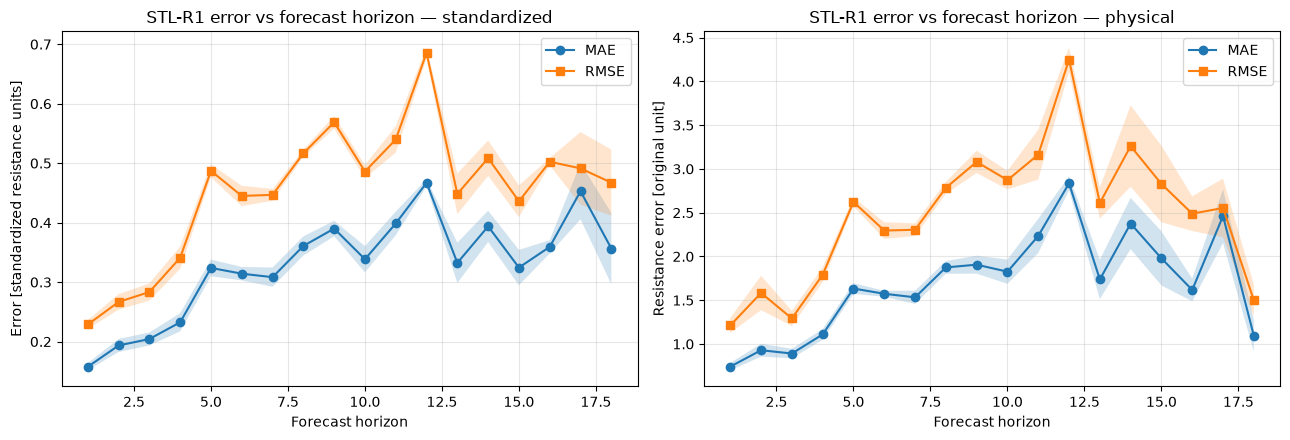

,horizon,MAE_std_mean,MAE_std_std,RMSE_std_mean,RMSE_std_std,MAE_phys_mean,MAE_phys_std,RMSE_phys_mean,RMSE_phys_std,N_component_min,N_component_max
0,1,0.1576,0.0060,0.2288,0.0075,0.7413,0.0426,1.2116,0.0851,44,45
1,2,0.1935,0.0110,0.2667,0.0130,0.9285,0.0739,1.5833,0.1969,41,45
2,3,0.2044,0.0109,0.2834,0.0145,0.8910,0.0541,1.2916,0.0867,39,45
3,4,0.2325,0.0153,0.3410,0.0187,1.1092,0.0616,1.7910,0.0850,35,42
4,5,0.3239,0.0140,0.4871,0.0110,1.6334,0.0612,2.6231,0.0509,35,42
5,6,0.3142,0.0113,0.4449,0.0171,1.5737,0.0339,2.2957,0.0948,34,42
6,7,0.3083,0.0162,0.4468,0.0100,1.5330,0.0754,2.3050,0.0725,33,42
7,8,0.3608,0.0161,0.5166,0.0060,1.8745,0.0723,2.7843,0.0672,31,42
8,9,0.3901,0.0130,0.5688,0.0107,1.9061,0.1028,3.0801,0.1278,26,40
9,10,0.3385,0.0221,0.4860,0.0110,1.8258,0.1388,2.8719,0.1054,27,41


In [7]:
# ---- forecast-horizon curves: component first -> equal average to R1 task ----
test_points = points_all[points_all['split'] == 'test'].copy()

# Calculate each SOC component separately
component_horizon = (
    test_points
    .groupby(['seed', 'component', 'horizon'])
    .agg(
        MAE_std=('abs_std', 'mean'),
        RMSE_std=('sq_std', lambda s: math.sqrt(s.mean())),
        MAE_phys=('abs_phys', 'mean'),
        RMSE_phys=('sq_phys', lambda s: math.sqrt(s.mean())),
        N=('yt_std', 'size'),
    )
    .reset_index()
)

# Equal average over SOC10/SOC50/SOC90
per_seed_h = (
    component_horizon
    .groupby(['seed', 'horizon'])
    .agg(
        MAE_std=('MAE_std', 'mean'),
        RMSE_std=('RMSE_std', 'mean'),
        MAE_phys=('MAE_phys', 'mean'),
        RMSE_phys=('RMSE_phys', 'mean'),
        N_component_min=('N', 'min'),
        N_component_max=('N', 'max'),
    )
    .reset_index()
)

hz = (
    per_seed_h
    .groupby('horizon')
    .agg(
        MAE_std_mean=('MAE_std', 'mean'),
        MAE_std_std=('MAE_std', 'std'),
        RMSE_std_mean=('RMSE_std', 'mean'),
        RMSE_std_std=('RMSE_std', 'std'),
        MAE_phys_mean=('MAE_phys', 'mean'),
        MAE_phys_std=('MAE_phys', 'std'),
        RMSE_phys_mean=('RMSE_phys', 'mean'),
        RMSE_phys_std=('RMSE_phys', 'std'),
        N_component_min=('N_component_min', 'first'),
        N_component_max=('N_component_max', 'first'),
    )
    .reset_index()
)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(hz['horizon'], hz['MAE_std_mean'], marker='o', label='MAE')
ax[0].fill_between(
    hz['horizon'],
    hz['MAE_std_mean'] - hz['MAE_std_std'],
    hz['MAE_std_mean'] + hz['MAE_std_std'],
    alpha=0.2
)
ax[0].plot(hz['horizon'], hz['RMSE_std_mean'], marker='s', label='RMSE')
ax[0].fill_between(
    hz['horizon'],
    hz['RMSE_std_mean'] - hz['RMSE_std_std'],
    hz['RMSE_std_mean'] + hz['RMSE_std_std'],
    alpha=0.2
)
ax[0].set_xlabel('Forecast horizon')
ax[0].set_ylabel('Error [standardized resistance units]')
ax[0].set_title('STL-R1 error vs forecast horizon — standardized')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(hz['horizon'], hz['MAE_phys_mean'], marker='o', label='MAE')
ax[1].fill_between(
    hz['horizon'],
    hz['MAE_phys_mean'] - hz['MAE_phys_std'],
    hz['MAE_phys_mean'] + hz['MAE_phys_std'],
    alpha=0.2
)
ax[1].plot(hz['horizon'], hz['RMSE_phys_mean'], marker='s', label='RMSE')
ax[1].fill_between(
    hz['horizon'],
    hz['RMSE_phys_mean'] - hz['RMSE_phys_std'],
    hz['RMSE_phys_mean'] + hz['RMSE_phys_std'],
    alpha=0.2
)
ax[1].set_xlabel('Forecast horizon')
ax[1].set_ylabel('Resistance error [original unit]')
ax[1].set_title('STL-R1 error vs forecast horizon — physical')
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

hz.round(4)


In [8]:
# ---- save full-200 STL-R1 outputs ----
prefix = 'stl_r1_full200'

training_history.to_csv(
    f'{prefix}_training_history_5seeds.csv',
    index=False
)
training_summary.to_csv(
    f'{prefix}_training_summary_5seeds.csv',
    index=False
)

points_all.to_csv(
    f'{prefix}_predictions_5seeds.csv',
    index=False
)
component_metrics.to_csv(
    f'{prefix}_component_metrics_per_seed.csv',
    index=False
)
component_summary.to_csv(
    f'{prefix}_component_metrics_5seed_summary.csv',
    index=False
)
task_metrics.to_csv(
    f'{prefix}_task_metrics_per_seed.csv',
    index=False
)
task_summary.to_csv(
    f'{prefix}_task_metrics_5seed_summary.csv',
    index=False
)
hz.to_csv(
    f'{prefix}_horizon_5seed_summary.csv',
    index=False
)

print(f'saved {prefix}_training_history_5seeds.csv')
print(f'saved {prefix}_training_summary_5seeds.csv')
print(f'saved {prefix}_predictions_5seeds.csv')
print(f'saved {prefix}_component_metrics_per_seed.csv')
print(f'saved {prefix}_component_metrics_5seed_summary.csv')
print(f'saved {prefix}_task_metrics_per_seed.csv')
print(f'saved {prefix}_task_metrics_5seed_summary.csv')
print(f'saved {prefix}_horizon_5seed_summary.csv')


saved stl_r1_full200_training_history_5seeds.csv
saved stl_r1_full200_training_summary_5seeds.csv
saved stl_r1_full200_predictions_5seeds.csv
saved stl_r1_full200_component_metrics_per_seed.csv
saved stl_r1_full200_component_metrics_5seed_summary.csv
saved stl_r1_full200_task_metrics_per_seed.csv
saved stl_r1_full200_task_metrics_5seed_summary.csv
saved stl_r1_full200_horizon_5seed_summary.csv


## Final STL-R1 baseline protocol

For each seed, this notebook trains all 200 epochs and selects:

**the epoch with the lowest validation R1 task loss over the complete 1–200 epoch range.**

The chosen checkpoint is then evaluated on the test set.

After this full-epoch STL-R1 result is accepted, use it as the fixed single-task R1 reference for later MTL comparisons. The previous patience-20 experiment can remain archived as a preliminary result, but should not be mixed into the final main comparison table.
